In [ ]:
# vis_barcode_plotstyle.py
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec

MM_PER_INCH = 25.4
SINGLE_COLUMN_MM = 88 * 0.65
DOUBLE_COLUMN_MM = 180
MAX_WIDTH_MM = 180
FONT_PT = 6
SMALL_FONT_PT = 5

def mm_to_inch(mm: float) -> float:
    return mm / MM_PER_INCH

# =========================
# 0) Global style parameters
# =========================
def setupstyle(double_column: bool = True, figure_height_mm: float = 42.0):
    fig_w_mm = DOUBLE_COLUMN_MM if double_column else SINGLE_COLUMN_MM
    fig_w_in = mm_to_inch(fig_w_mm)
    fig_h_in = mm_to_inch(figure_height_mm)

    plt.rcParams.update({
        'figure.figsize': (fig_w_in, fig_h_in),
        'figure.dpi': 600, 'savefig.dpi': 600,
        'savefig.bbox': 'standard', 'savefig.pad_inches': 0.0,

        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'],
        'font.size': FONT_PT,
        'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',

        # 5-7 pt body text; use 6 pt here and 5 pt for ticks.
        'axes.labelsize': FONT_PT,
        'axes.titlesize': FONT_PT,
        'xtick.labelsize': SMALL_FONT_PT,
        'ytick.labelsize': SMALL_FONT_PT,
        'legend.fontsize': FONT_PT,

        # Axes and ticks.
        'axes.linewidth': 0.35,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.width': 0.35,
        'ytick.major.width': 0.35,
        'xtick.major.size': 1.8,
        'ytick.major.size': 1.8,

        # Other settings.
        'axes.grid': False,
        'patch.edgecolor': 'none',
        'patch.linewidth': 0.0,
        'axes.titlepad': 2,
        'axes.labelpad': 2,
    })

    # Optional: register Arial
    try:
        arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
        fm.fontManager.addfont(arial_path)
        plt.rcParams['font.family'] = 'Arial'
    except Exception:
        pass

def create_custom_colormap(color_false_hex, color_true_hex):
    return mcolors.LinearSegmentedColormap.from_list(
        "cmap_false_to_true", [color_false_hex, color_true_hex]
    )

def wrap_score_label(label: str) -> str:
    if label.endswith("_Dx"):
        return label[:-3] + "\n_Dx"
    if label.endswith("_R"):
        return label[:-2] + "\n_R"
    return label

# =========================
# 1) Configuration
# =========================
CONFIG = {
    "data": {
        "csv_path": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv"
    },
    "results": {
        "output_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots"
    },
    "palette": {
        # Match the manuscript: True = blue and False = orange (an Okabe-Ito approximation)
        "decision_true":  "#9C89B8",
        "decision_false": "#F3857D",
    }
}

def with_palette(config, **overrides):
    cfg = copy.deepcopy(config)
    base = cfg["palette"]
    cfg["palette"] = {**base, **{k: v for k, v in overrides.items() if v is not None}}
    return cfg

# =========================
# 2) Core plotting function.
# =========================
def plot_barcode_for_score(
    df: pd.DataFrame,
    score_col: str,                    # "Probabilistic_Score" or "Consistency_Score".
    cfg: dict = CONFIG,
    title: str = None,
    xlabel: str = None,
    ylabel_top: str = None,            # Y-axis label for the upper bars.
    ylabel_bottom: str = "Decision",   # Y-axis label for the lower bars.
    base_filename: str = "barcode_plot",
    dpi: int = 300,
    dynamic_width: bool = False,       # When True, widen by sample count without exceeding the maximum width.
    double_column: bool = False,
    figure_height_mm: float = 30.5, # 42.0,
    export_preview_png: bool = True,
):
    setupstyle(double_column=double_column, figure_height_mm=figure_height_mm)

    palette = cfg["palette"]
    outdir = cfg["results"]["output_dir"]
    os.makedirs(outdir, exist_ok=True)

    # Sort (ascending)
    df_sorted = df.sort_values(by=score_col).reset_index(drop=True)

    # Decisions and scores
    scores = df_sorted[score_col].astype(float).values.reshape(1, -1)
    decisions = df_sorted['final_decision'].astype(int).values.reshape(1, -1)

    # Color mapping: gradient on top, two discrete colors below
    cmap_grad = create_custom_colormap(palette['decision_false'], palette['decision_true'])
    cmap_disc = mcolors.ListedColormap([palette['decision_false'], palette['decision_true']])

    # Optional: widen by sample count; set False when journal layout requires a fixed width
    if dynamic_width:
        n = scores.shape[1]
        base_w_mm = DOUBLE_COLUMN_MM if double_column else SINGLE_COLUMN_MM
        width_mm = min(MAX_WIDTH_MM, max(base_w_mm, base_w_mm * n / 600))
        width_in = mm_to_inch(width_mm)
        plt.rcParams['figure.figsize'] = (width_in, plt.rcParams['figure.figsize'][1])

    # --- Layout: use a right column for the colorbar and legend to prevent the legend from widening the export ---
    top_margin = 0.84 if title else 0.96
    bottom_margin = 0.22 if xlabel else 0.10
    fig = plt.figure(figsize=plt.rcParams['figure.figsize'], constrained_layout=False)
    gs = GridSpec(
        nrows=2, ncols=2, figure=fig,
        width_ratios=[0.78, 0.22],
        height_ratios=[1, 1],
        left=0.24, right=0.98, top=top_margin, bottom=bottom_margin,
        wspace=0.10, hspace=0.20
    )
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_bottom= fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_cbar  = fig.add_subplot(gs[0, 1])
    ax_cbar.set_anchor("W")
    box = ax_cbar.get_position()
    ax_cbar.set_position([
        box.x0,
        box.y0,
        box.width * 0.35,
        box.height
    ])

    ax_legend = fig.add_subplot(gs[1, 1])

    # Use pcolormesh for editable vector cells; PNG is only a preview.
    n_cases = scores.shape[1]
    x_edges = np.arange(n_cases + 1)
    y_edges = np.array([0, 1])
    mesh_kwargs = dict(shading='flat', edgecolors='none', linewidth=0, antialiased=False, rasterized=False)
    im_top = ax_top.pcolormesh(x_edges, y_edges, scores, cmap=cmap_grad, **mesh_kwargs)
    ax_bottom.pcolormesh(x_edges, y_edges, decisions, cmap=cmap_disc, vmin=0, vmax=1, **mesh_kwargs)

    # Axis styling (barcode plots usually hide ticks and spines while retaining clean boundaries)
    for ax in [ax_top, ax_bottom]:
        ax.set_xlim(0, n_cases)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # Unify titles and labels
    if title:
        # Left alignment resembles journal-caption styling
        fig.suptitle(title, fontsize=FONT_PT, x=0.01, y=0.985, ha='left', weight='bold')
    ax_top.set_ylabel(ylabel_top or (score_col.replace('_', ' ') + "\n"), rotation=0, ha='right', va='center')
    # ax_top.set_ylabel(
    #     ylabel_top or wrap_score_label(score_col),
    #     rotation=0,
    #     ha='right',
    #     va='center',
    #     multialignment='center',
    #     linespacing=0.9,
    # )
    ax_bottom.set_ylabel(ylabel_bottom, rotation=0, ha='right', va='center')
    if xlabel:
        ax_bottom.set_xlabel(xlabel)

    # Colorbar (right side, no border, thin ticks)
    cbar = plt.colorbar(im_top, cax=ax_cbar)
    # cbar.set_label(score_col.replace('_', ' '))
    cbar.outline.set_visible(False)
    finite_scores = scores[np.isfinite(scores)]
    if finite_scores.size:
        score_min = float(np.nanmin(finite_scores))
        score_max = float(np.nanmax(finite_scores))
    else:
        score_min = score_max = np.nan
    if np.isfinite(score_min) and np.isfinite(score_max) and score_min < score_max:
        cbar.set_ticks([score_min, score_max])
        cbar.set_ticklabels([f"{score_min:.2g}", f"{score_max:.2g}"])
    cbar.ax.tick_params(size=0, labelsize=SMALL_FONT_PT, pad=1)

    # Legend: keep it within the page area so bbox_inches='tight' does not change the final width.
    legend_patches = [
        mpatches.Patch(color=palette['decision_true'],  label='Correct'),
        mpatches.Patch(color=palette['decision_false'], label='Incorrect')
    ]
    ax_legend.axis('off')
    ax_legend.legend(
        handles=legend_patches, loc='center left',
        frameon=False, handlelength=0.8, handleheight=0.8, handletextpad=0.4, borderaxespad=0.0
    )

    # Export
    base = os.path.join(outdir, base_filename)
    fig.savefig(base + ".pdf", format="pdf", dpi=dpi, bbox_inches=None)
    fig.savefig(base + ".eps", format="eps", dpi=dpi, bbox_inches=None)
    fig.savefig(base + ".svg", format="svg", dpi=dpi, bbox_inches=None)
    if export_preview_png:
        fig.savefig(base + ".png", format="png", dpi=dpi, bbox_inches=None)
    # plt.close()
    preview_msg = " / " + base + ".png" if export_preview_png else ""
    print(f"Saved: {base}.pdf / {base}.eps / {base}.svg{preview_msg}")





Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/ProbScore_Dx.pdf / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/ProbScore_Dx.eps / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/ProbScore_Dx.svg / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/ProbScore_Dx.png
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/Consistency_Dx.pdf / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/Consistency_Dx.eps / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/Consistency_Dx.svg / /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/Consistency_Dx.png
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/barcode_plots/LingCert_Dx.pdf / /mnt/bulk-sirius/lizhang/LiWS/Medical_Ll

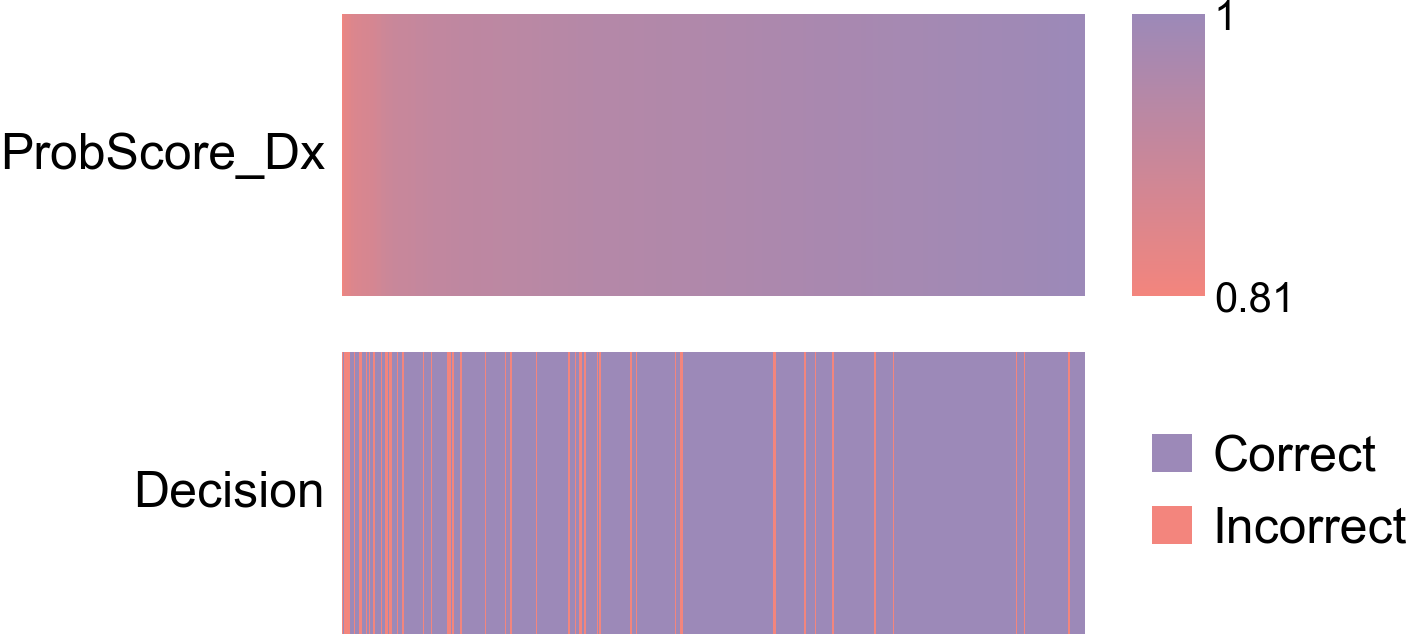

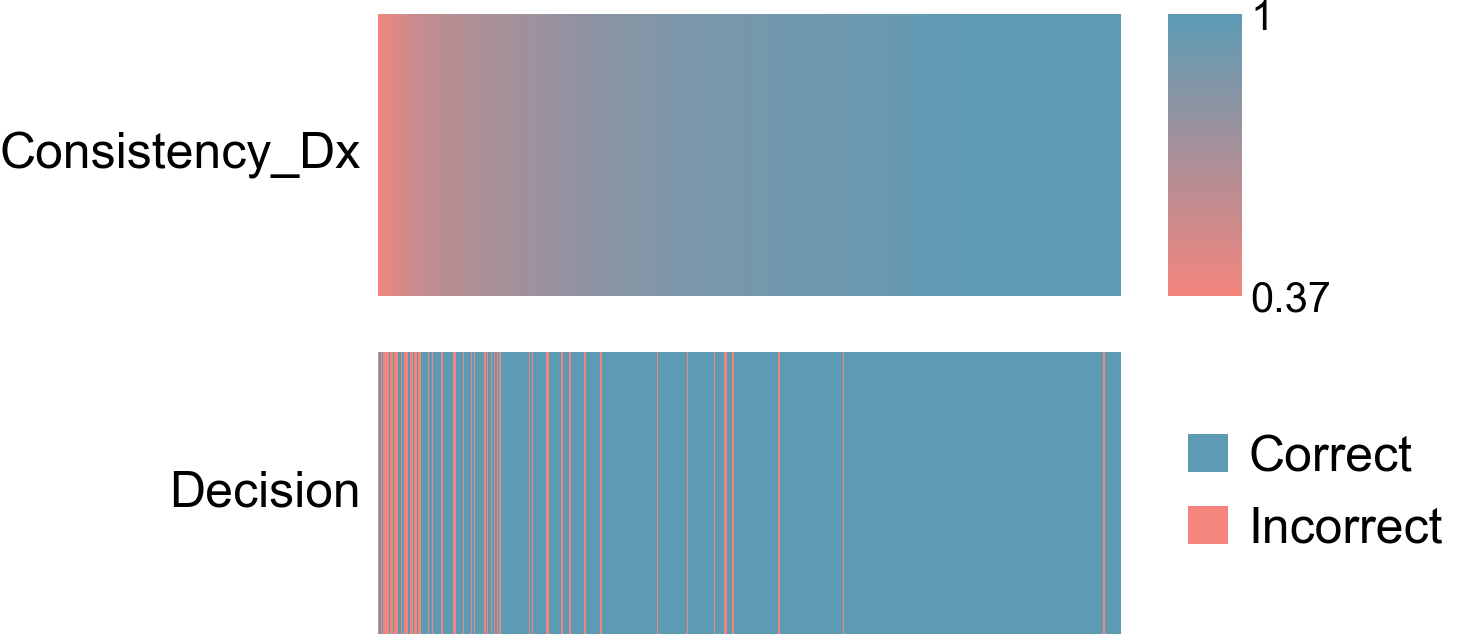

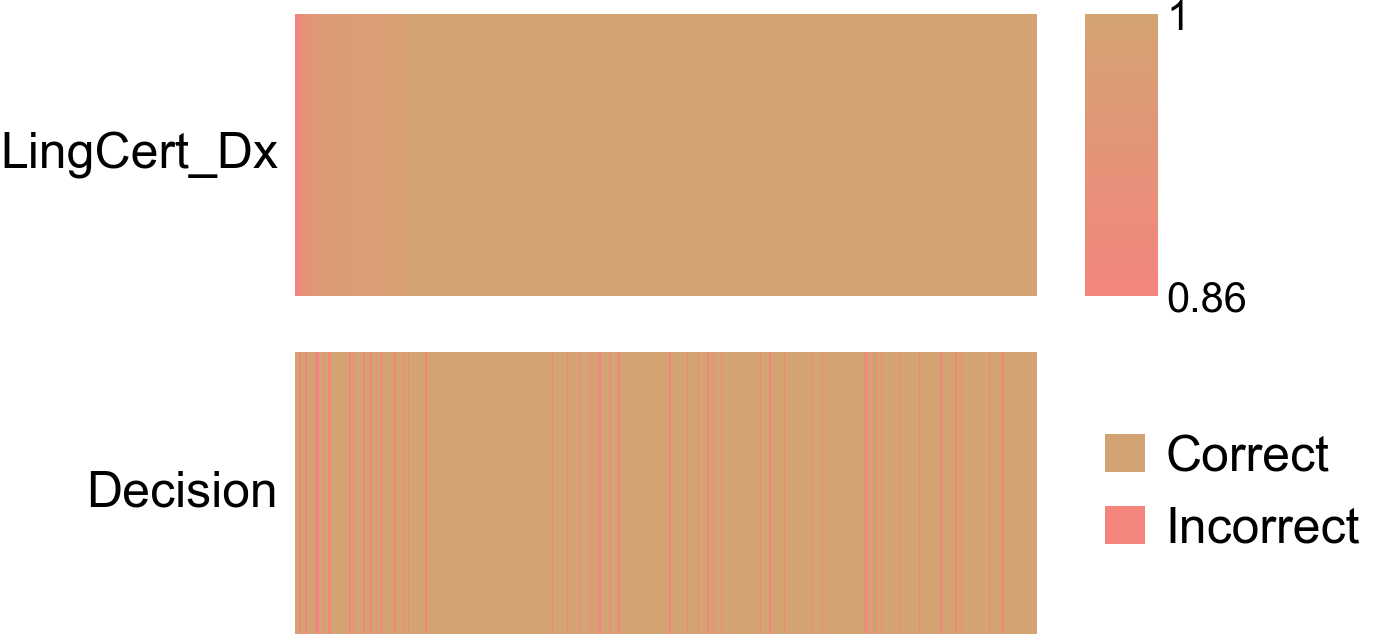

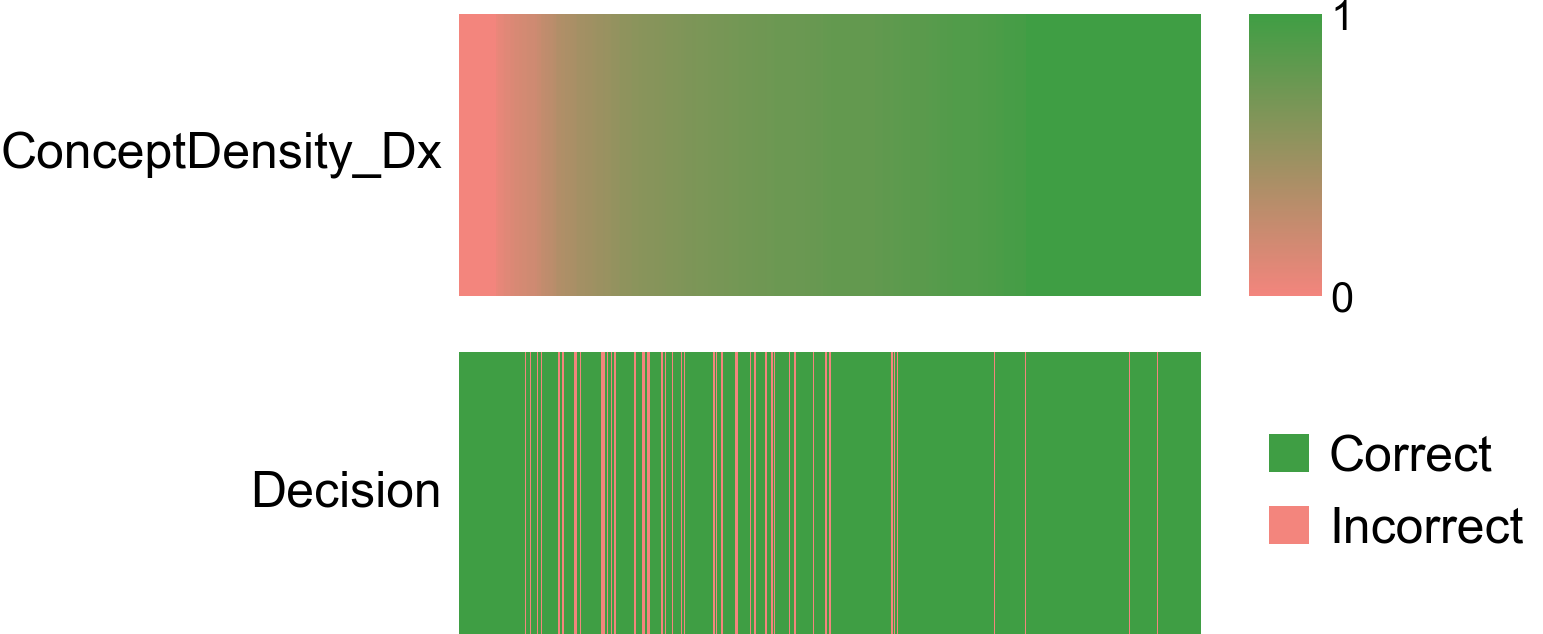

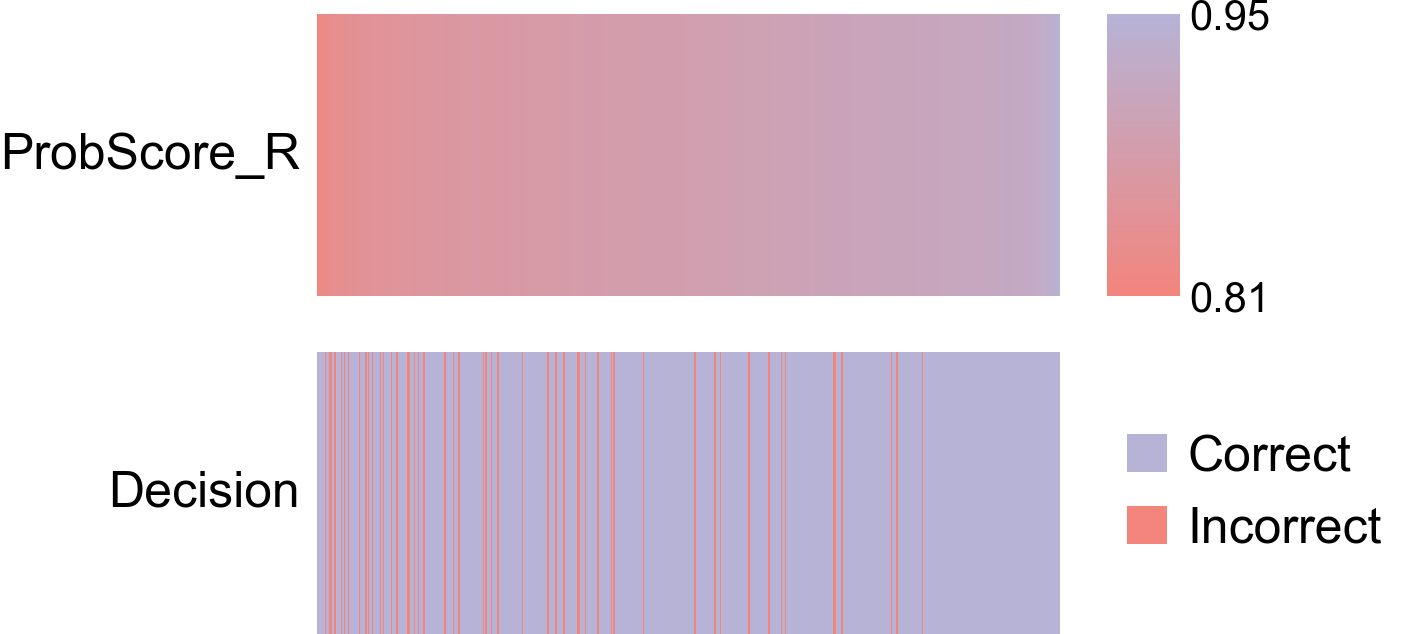

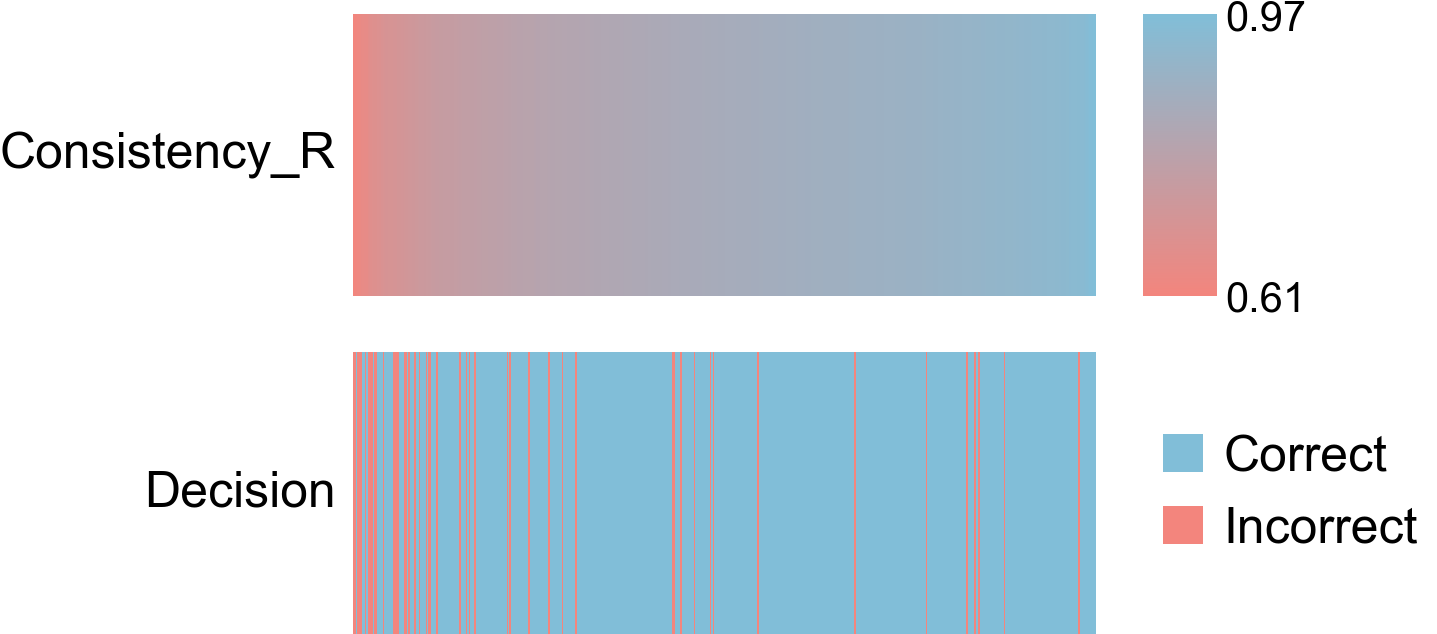

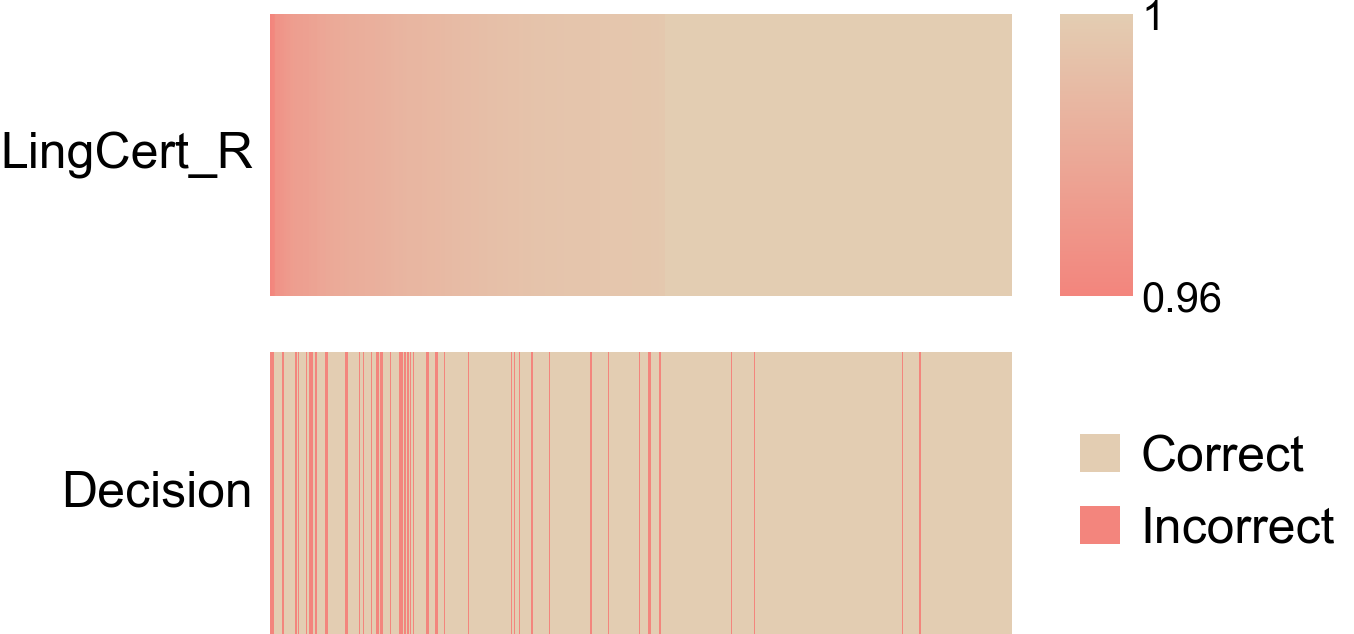

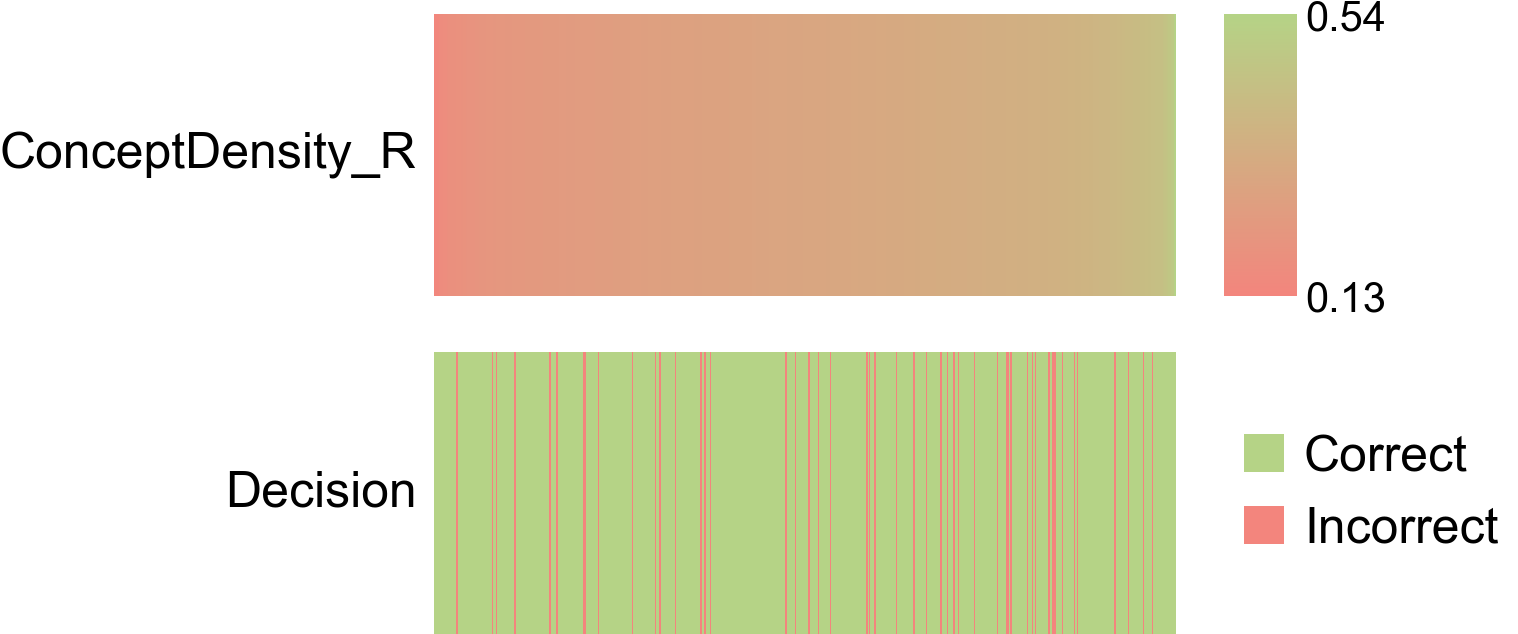

In [26]:

# =========================
# 3) Call: draw one figure for each score
# =========================
if __name__ == "__main__":
    csv_path = CONFIG['data']['csv_path']
    outdir   = CONFIG['results']['output_dir']
    os.makedirs(outdir, exist_ok=True)

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("❌ File not found:", csv_path)
        raise SystemExit

    # 1) ProbScore_Dx
    plot_barcode_for_score(
        df=df,
        score_col="ProbScore_Dx",
        cfg=CONFIG,
        # title="Case distribution by confidence and correctness",
        # xlabel="Individual cases (sorted by ascending probabilistic score)",
        ylabel_top="ProbScore_Dx",
        base_filename="ProbScore_Dx"
    )

    # 2) Consistency_Dx
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#5D9BB5",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="Consistency_Dx",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending consistency score)",
        ylabel_top="Consistency_Dx",
        base_filename="Consistency_Dx"
    )

    # 3) LingCert_Dx
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#D4A373",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="LingCert_Dx",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending consistency score)",
        ylabel_top="LingCert_Dx",
        base_filename="LingCert_Dx"
    )

    # 4) ConceptDensity_Dx
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#3F9E44",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="ConceptDensity_Dx",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending consistency score)",
        ylabel_top="ConceptDensity_Dx",
        base_filename="ConceptDensity_Dx"
    )

    # 5) ProbScore_R
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#B6B3D6",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="ProbScore_R",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending consistency score)",
        ylabel_top="ProbScore_R",
        base_filename="ProbScore_R"
    )

    # 6) Consistency_R
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#81BED8",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="Consistency_R",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending consistency score)",
        ylabel_top="Consistency_R",
        base_filename="Consistency_R"
    )

    # 7) LingCert_R
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#E3CDB2",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="LingCert_R",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending Consistency_Dx)",
        ylabel_top="LingCert_R",
        base_filename="LingCert_R"
    )

    # 8) ConceptDensity_R
    # Use with_palette to change only the True/False colors without changing global settings
    run_cfg = with_palette(CONFIG,
                           decision_true="#B5D386",
                           decision_false="#F3857D")
    plot_barcode_for_score(
        df=df,
        score_col="ConceptDensity_R",
        cfg=run_cfg,
        title=None,  # In panel layouts, this is usually explained by the overall title or figure caption.
        # xlabel="Individual cases (sorted by ascending Consistency_Dx)",
        ylabel_top="ConceptDensity_R",
        base_filename="ConceptDensity_R"
    )